# <b><font size=7 color='orange'> Computer Assignment 3</font></b>

<b><font color="orange" size="6">Collaborators:</font></b><br>
<font color="orange" size="5">
  <i>
     Mehrad Liviyan - 810101501<br>
     Shayan Saeedi - 810101442
  </i>
</font>


<!-- Markdown cell content starts -->
<!DOCTYPE html>
<html>
<head>
<style>
  body {
    background: #0f172a;
    color: #e5e7eb;
    font-family: Inter, sans-serif;
  }
  .assignment {
    max-width: 900px;
    margin: auto;
    padding: 20px;
    background: #1f2937;
    border-radius: 12px;
    border: 1px solid #374151;
  }
  h1 {
    color: #22d3ee;
  }
  h2 {
    border-left: 4px solid #22d3ee;
    padding-left: 8px;
  }
  table {
    width: 100%;
    border-collapse: collapse;
    margin-top: 12px;
  }
  th, td {
    border: 1px solid #374151;
    padding: 8px;
    text-align: left;
  }
  th {
    background: #111827;
  }
</style>
</head>
<body>
<div class="assignment">
  <h1>Computer Vision Assignment</h1>
  <p><strong>Course:</strong> Computer Vision<br>
     <strong>Deadline:</strong> XXXX<br>
     <strong>Total Points:</strong> 100</p>

  <h2>Objective</h2>
  <ol>
    <li>Use pretrained CNNs for classification, detection, segmentation</li>
    <li>Perform preprocessing</li>
    <li>Run inference on input images</li>
    <li>Evaluate results</li>
  </ol>

  <h2>Grading Breakdown</h2>
  <table>
    <tr><th>Criterion</th><th>Description</th><th>Points</th></tr>
    <tr><td>Correct preprocessing</td><td>Resizing, normalization, tensor conversion</td><td>20</td></tr>
    <tr><td>Correct model usage</td><td>Proper pretrained model inference</td><td>20</td></tr>
    <tr><td>Visualization quality</td><td>Clear side-by-side figures</td><td>20</td></tr>
    <tr><td>Analysis and discussion</td><td>Interpretation and insights</td><td>40</td></tr>
    <tr><td colspan="2"><strong>Total</strong></td><td><strong>100</strong></td></tr>
  </table>

  <h4>Answer all questions colored in red, or complete all parts in "#TO DO" sections.</h4>

</div>
</body>
</html>
<!-- Markdown cell content ends -->


## 0. Setup and Installation

In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm segment-anything ultralytics
!pip install -q pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


# Import Required Libraries

In [2]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from ultralytics import YOLO
import timm
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu


## 1. Show All Input Images
<span style="color:red">
Plot all the images in a single figure.
</span>

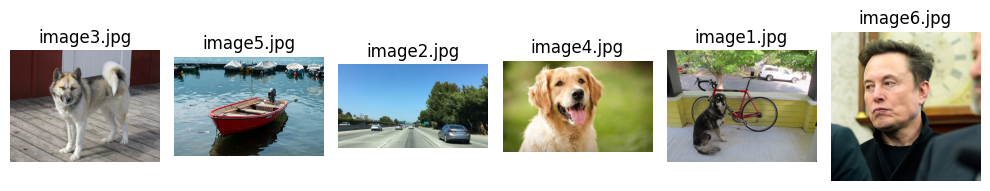

In [3]:
# TO DO

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder_path = '../Description'

image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

fig, axes = plt.subplots(1, len(image_files), figsize=(10, 10))

if len(image_files) == 1:
    axes = [axes]

for ax, image_file in zip(axes, image_files):
    img = mpimg.imread(os.path.join(folder_path, image_file))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(image_file)

plt.tight_layout()
plt.show()


### **Analysis & Observations**

<div dir="rtl">

در بخش بررسی داده‌ها می‌بینیم که تصاویر موجود در دیتاست تنوع بالایی دارن و از صحنه‌های مختلفی مثل محیط‌های شهری، طبیعت و اشیاء گوناگون تشکیل شدن. این تنوع باعث میشه بتونیم خوب ارزیابی کنیم که مدل‌های از پیش آموزش‌دیده تا چه حد می‌تونن **تعمیم‌پذیر** باشن؛ یعنی آیا فقط روی یک نوع تصویر خوب عمل می‌کنن یا می‌تونن در شرایط و فضاهای متفاوت هم عملکرد مناسبی داشته باشن. هرچی تنوع داده‌ها بیشتر باشه، قضاوت درباره قدرت واقعی مدل دقیق‌تر خواهد بود.

از طرف دیگه، تصاویر ورودی اندازه‌ها و نسبت‌های ابعاد متفاوتی دارن. بعضی تصاویر کشیده هستن، بعضی مربعی و بعضی هم رزولوشن بالاتری دارن. این موضوع نشون می‌ده که انجام مرحله‌ی **پیش‌پردازش (Preprocessing)** کاملاً ضروریه. چون مدل‌های CNN مثل ResNet فقط می‌تونن تصاویر با اندازه‌ی ثابت (مثلاً ‎224×224‎) رو دریافت کنن، باید قبل از ورود تصویر به مدل، عملیات‌هایی مثل تغییر اندازه، برش یا پد کردن انجام بشه تا همه‌ی تصاویر با ورودی مدل هماهنگ بشن و عملکرد مدل دچار مشکل نشه.


---
## 2. Task 1 – Image Classification
---
In this task, you are to use pretrained **EfficientNet-B4** model from torchvision/timm with 1000 classes.

<span style="color:red">
Explain the functionality of the model briefly and indicate the dataset it is trained on.
</span>

**Required preprocessing**:
You are asked to design and apply a **12‑step preprocessing pipeline** to prepare real‑world images for classification with EfficientNet‑B4.

<span style="color:red"> For each step, briefly explain why it is useful.</span>


### Steps to include:
1. Convert to NumPy for OpenCV operations
2. Apply Gaussian blur  
3. Perform unsharp masking – Enhance edges and improve clarity
4. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)improve local contrast.
5. Convert back to PIL format.
6. Pad to square shape – Preserve aspect ratio before resizing.
7. Resize with high‑quality antialiasing.
8. Apply random rotation and random crop.
9. Apply color jitter and random grayscale.
10. Convert to tensor.
11. Normalize with ImageNet mean and std.
12. Add batch dimension.


<div dir="rtl">


## معرفی مدل (Model Overview)

مدل **EfficientNet-B4** یکی از اعضای مهم و موفق خانواده‌ی **EfficientNet** است که توسط تیم **Google Research** معرفی شد و خیلی سریع به‌عنوان یکی از بهترین معماری‌ها در حوزه‌ی **طبقه‌بندی تصویر (Image Classification)** شناخته شد. ایده‌ی اصلی پشت طراحی EfficientNet این بود که برخلاف رویکردهای قدیمی، به‌جای بزرگ‌تر و پیچیده‌تر کردن بی‌هدف شبکه‌های عصبی، مدلی ساخته شود که بتواند با **حداقل مصرف منابع محاسباتی، بیشترین دقت ممکن** را ارائه دهد. به همین دلیل، EfficientNet-B4 در مقایسه با بسیاری از معماری‌های قدیمی‌تر مثل VGG و حتی برخی نسخه‌های ResNet، با تعداد پارامتر کمتر یا مشابه، عملکرد دقیق‌تر و کارآمدتری دارد.

EfficientNet-B4 به‌عنوان یک مدل **میانی رو به بزرگ** در این خانواده، تعادل بسیار خوبی بین دقت و هزینه‌ی محاسباتی برقرار می‌کند. این مدل نه آن‌قدر کوچک است که دقت فدای سرعت شود و نه آن‌قدر بزرگ که برای استفاده‌ی عملی و واقعی غیرقابل‌اجرا باشد. به همین خاطر، در بسیاری از پروژه‌های تحقیقاتی و کاربردهای صنعتی که هم دقت بالا و هم بهینه بودن منابع اهمیت دارد، EfficientNet-B4 یک انتخاب بسیار منطقی و محبوب محسوب می‌شود.


## نوآوری اصلی: Compound Scaling

قبل از معرفی EfficientNet، روش رایج برای افزایش قدرت مدل‌های بینایی ماشین این بود که تنها یکی از ابعاد شبکه را افزایش دهند. برای مثال، بعضی مدل‌ها با اضافه کردن لایه‌های بیشتر، شبکه را عمیق‌تر می‌کردند که این کار اغلب باعث سخت‌تر شدن فرآیند آموزش و بروز مشکلاتی مثل ناپدید شدن گرادیان می‌شد. در برخی موارد دیگر، تعداد فیلترها افزایش داده می‌شد که اگرچه دقت را بالا می‌برد، اما باعث رشد شدید تعداد پارامترها و هزینه‌ی محاسباتی می‌شد. افزایش اندازه‌ی تصویر ورودی هم روش دیگری بود که معمولاً منجر به مصرف حافظه و زمان پردازش بسیار بالا می‌شد.

EfficientNet برای اولین بار یک رویکرد کاملاً متفاوت به نام **Compound Scaling** ارائه داد. در این روش، به‌جای بزرگ کردن تصادفی یا جداگانه‌ی یک بُعد، هر سه بُعد اصلی شبکه یعنی **عمق شبکه (Depth)**، **عرض شبکه (Width)** و **رزولوشن تصویر ورودی (Resolution)** به‌صورت **هماهنگ، متعادل و مبتنی بر محاسبات دقیق** با هم افزایش داده می‌شوند. این کار باعث می‌شود مدل بتواند اطلاعات بیشتری را از تصویر استخراج کند، بدون اینکه به شکل غیرضروری سنگین یا ناکارآمد شود.

نسخه‌ی **EfficientNet-B4** یکی از خروجی‌های مستقیم همین استراتژی است. این مدل به‌صورت خاص برای ورودی‌هایی با اندازه‌ی **۳۸۰×۳۸۰ پیکسل** طراحی شده است؛ عددی که کاملاً حساب‌شده و بر اساس همان ضرایب Compound Scaling انتخاب شده تا بهترین توازن بین دقت، سرعت و مصرف منابع ایجاد شود. در نتیجه، EfficientNet-B4 قادر است جزئیات بیشتری از تصویر را نسبت به نسخه‌های کوچک‌تر استخراج کند، در حالی که همچنان از نظر محاسباتی قابل کنترل باقی می‌ماند.


## دیتاست آموزش (Pretraining Dataset)

مدل **EfficientNet-B4** به‌صورت از پیش آموزش‌دیده (**Pretrained**) روی دیتاست بسیار معروف و استاندارد **ImageNet** آموزش داده شده است. دیتاست ImageNet یکی از بزرگ‌ترین و تأثیرگذارترین دیتاست‌ها در پیشرفت حوزه‌ی بینایی ماشین به شمار می‌رود و شامل حدود **۱.۲ میلیون تصویر آموزشی** است که در **۱۰۰۰ کلاس مختلف** دسته‌بندی شده‌اند. این کلاس‌ها دامنه‌ی بسیار گسترده‌ای از اشیاء دنیای واقعی را شامل می‌شوند؛ از انواع حیوانات و پرندگان گرفته تا وسایل نقلیه، ابزارها، اشیاء خانگی و عناصر روزمره‌ی زندگی.

به دلیل این حجم بالا و تنوع زیاد داده‌ها، EfficientNet-B4 در فرآیند پیش‌آموزش یاد گرفته است که ویژگی‌های عمومی و پایه‌ای تصاویر را به‌خوبی استخراج کند؛ ویژگی‌هایی مثل **لبه‌ها، بافت‌ها، الگوهای تکرارشونده و ساختارهای هندسی**. این یادگیری در لایه‌های ابتدایی و میانی مدل ذخیره شده و باعث می‌شود که EfficientNet-B4 برای **Transfer Learning** گزینه‌ای بسیار قدرتمند باشد. به بیان ساده‌تر، حتی اگر دیتاست جدید کوچک باشد یا کلاس‌های آن با ImageNet متفاوت باشند، این مدل می‌تواند با کمی تنظیم (Fine-tuning) عملکرد بسیار خوبی از خود نشان دهد و در پروژه‌های واقعی نتایج قابل اعتمادی ارائه کند.

<div dir="rtl">

## توضیح کامل مراحل پیش‌پردازش (Preprocessing Pipeline)

### 1. **تبدیل تصویر به NumPy برای عملیات OpenCV**

در اولین قدم، تصویر رو به فرمت **NumPy Array** تبدیل می‌کنیم. دلیلش اینه که کتابخونه‌ی **OpenCV** (که برای پردازش‌های حرفه‌ای تصویر مثل فیلترگذاری و افزایش کنتراست استفاده میشه) مستقیماً با آرایه‌های عددی کار می‌کنه، نه با فرمت‌های شیءمحور مثل PIL. این تبدیل در واقع پلی بین دنیای پردازش کلاسیک تصویر و پردازش مبتنی بر یادگیری عمیقه.


### 2. **اعمال محو کردن گوسی (Gaussian Blur)**

در این مرحله با استفاده از **Gaussian Blur** تصویر رو کمی نرم و مات می‌کنیم. این کار باعث میشه نویزهای ریز و ناخواسته‌ای که معمولاً توی تصاویر واقعی وجود دارن (مثل نویز دوربین یا جزئیات خیلی ریز و بی‌اهمیت) کاهش پیدا کنن. حذف این نویزها کمک می‌کنه مدل به‌جای تمرکز روی اطلاعات اضافی، روی ساختارهای اصلی تصویر تمرکز کنه.

### 3. **انجام Unsharp Masking برای تقویت لبه‌ها**

بعد از اینکه تصویر کمی محو شد، از تکنیک **Unsharp Masking** استفاده می‌کنیم تا لبه‌ها و مرزهای اشیاء دوباره تقویت بشن. شاید اسمش گمراه‌کننده باشه، ولی این روش دقیقاً برای **تیزتر کردن تصویر** به کار میره. این کار باعث میشه خطوط، مرزها و ساختارهای مهم تصویر واضح‌تر بشن و شبکه عصبی بتونه ویژگی‌های معنادار رو بهتر استخراج کنه.

### 4. **اعمال CLAHE برای بهبود کنتراست محلی**

در این مرحله از **CLAHE (Contrast Limited Adaptive Histogram Equalization)** استفاده می‌کنیم. این تکنیک کنتراست تصویر رو به‌صورت محلی افزایش میده، نه کلی. یعنی اگر بخشی از تصویر خیلی تاریک یا خیلی روشن باشه، CLAHE کمک می‌کنه جزئیات اون ناحیه بهتر دیده بشه، بدون اینکه نویز بیش از حد تقویت بشه. این موضوع مخصوصاً برای تصاویر با نور نامناسب یا سایه‌های شدید خیلی مهمه.

### 5. **تبدیل دوباره تصویر به فرمت PIL**

بعد از انجام عملیات OpenCV، تصویر رو دوباره به فرمت **PIL** برمی‌گردونیم. دلیلش اینه که اکثر ابزارهای آماده‌ی PyTorch در torchvision.transforms با تصاویر PIL بهتر و راحت‌تر کار می‌کنن. این مرحله باعث میشه بتونیم از تبدیل‌های استاندارد و بهینه‌ی PyTorch استفاده کنیم.

### 6. **پد کردن تصویر به شکل مربعی (حفظ نسبت ابعاد)**

چون تصاویر واقعی معمولاً نسبت‌های ابعاد مختلفی دارن، در این مرحله تصویر رو به‌جای کش دادن، **پد (Padding)** می‌کنیم تا مربعی بشه. این کار باعث میشه نسبت ابعاد اصلی تصویر حفظ بشه و اشیاء داخل تصویر دچار تغییر شکل نشن. مثلاً یک دایره کشیده نشه و تبدیل به بیضی نشه.

### 7. **تغییر اندازه با آنتی‌الیاسینگ با کیفیت بالا**

بعد از مربعی شدن تصویر، اون رو به اندازه‌ی مورد انتظار مدل (مثلاً **۳۸۰×۳۸۰ برای EfficientNet-B4**) تغییر می‌دیم. استفاده از **آنتی‌الیاسینگ** باعث میشه هنگام کوچک یا بزرگ کردن تصویر، لبه‌ها دچار شکستگی یا نویز نشدن و کیفیت کلی تصویر حفظ بشه.

### 8. **چرخش و برش تصادفی (Random Rotation & Crop)**

در این مرحله با چرخش و برش تصادفی تصویر، تنوع داده‌ها رو بالا می‌بریم. این کار کمک می‌کنه مدل نسبت به تغییر زاویه، موقعیت و کادربندی اشیاء حساس نباشه و در شرایط واقعی عملکرد پایدارتری داشته باشه. به‌نوعی، مدل یاد می‌گیره که شیء رو از زوایای مختلف بشناسه.

### 9. **اعمال تغییرات رنگ و خاکستری تصادفی**

با **Color Jitter** و تبدیل تصادفی به خاکستری، شرایط نوری مختلف رو شبیه‌سازی می‌کنیم. این کار باعث میشه مدل کمتر به رنگ وابسته باشه و بیشتر روی شکل، بافت و ساختار اشیاء تمرکز کنه؛ چیزی که برای تعمیم‌پذیری مدل خیلی مهمه.

### 10. **تبدیل تصویر به Tensor**

در این مرحله تصویر به **Tensor** تبدیل میشه؛ یعنی فرمت عددی‌ای که PyTorch برای پردازش استفاده می‌کنه. همچنین ترتیب ابعاد از (Height, Width, Channel) به (Channel, Height, Width) تغییر می‌کنه و مقادیر پیکسل‌ها به بازه‌ی [0, 1] منتقل می‌شن.

### 11. **نرمال‌سازی با میانگین و انحراف معیار ImageNet**

در این مرحله تصویر با استفاده از **میانگین و انحراف معیار دیتاست ImageNet** نرمال‌سازی میشه. این کار باعث میشه توزیع داده‌های ورودی شبیه داده‌هایی باشه که مدل در زمان آموزش دیده و در نتیجه، مدل عملکرد دقیق‌تر و پایدارتری داشته باشه.

### 12. **اضافه کردن بعد Batch**

در آخر، یک بعد جدید به تصویر اضافه می‌کنیم تا شکل داده مطابق انتظار مدل‌های PyTorch بشه؛ یعنی (Batch, Channel, Height, Width). حتی اگر فقط یک تصویر داشته باشیم، این بعد لازمه تا تصویر قابل ورود به مدل باشه.



--- Results for ../Description/image3.jpg ---


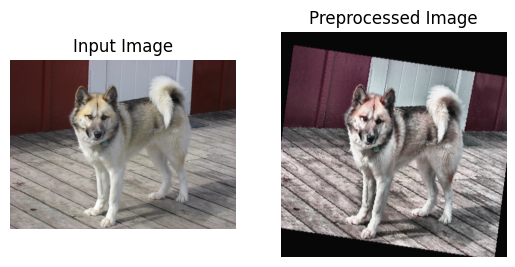

Top predictions:
1. malamute (29.21%)
2. Eskimo dog (9.32%)
3. Norwegian elkhound (7.86%)
4. German shepherd (4.44%)
5. timber wolf (2.38%)

--- Results for ../Description/image4.jpg ---


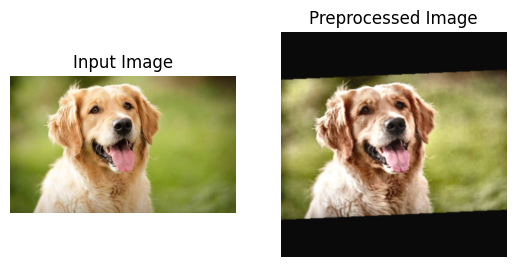

Top predictions:
1. golden retriever (41.32%)
2. Labrador retriever (2.09%)
3. Brittany spaniel (1.77%)
4. tennis ball (0.79%)
5. clumber (0.78%)

--- Results for ../Description/image5.jpg ---


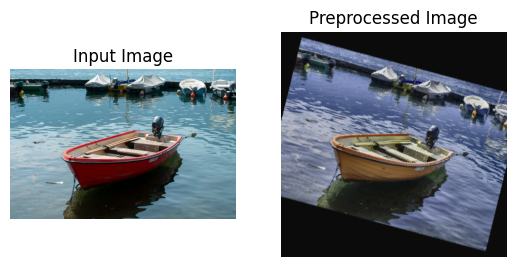

Top predictions:
1. boathouse (15.80%)
2. lakeside (9.17%)
3. dock (8.45%)
4. paddle (6.65%)
5. canoe (4.38%)

--- Results for ../Description/image6.jpg ---


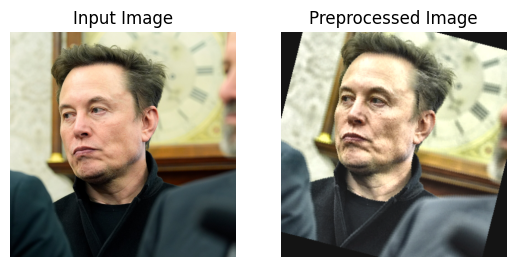

Top predictions:
1. wall clock (12.06%)
2. analog clock (11.34%)
3. barometer (11.14%)
4. barbershop (4.21%)
5. stopwatch (3.23%)


In [14]:
import timm
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageFilter, ImageOps
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from typing import Tuple

# Load model once
class_model = timm.create_model( "efficientnet_b4", pretrained=True, num_classes=1000)
class_model.eval().to(device)

# ImageNet labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(url).text.strip().split("\n")

# Preprocessing
def preprocessing(img: Image.Image) -> torch.Tensor:
    # 1. Convert to NumPy for OpenCV operations
    img_np = np.array(img)

    # 2. Apply Gaussian blur
    img_np = cv2.GaussianBlur(img_np, (5, 5), sigmaX=0)

    # 3. Unsharp masking (edge enhancement)
    blurred = cv2.GaussianBlur(img_np, (9, 9), sigmaX=10)
    img_np = cv2.addWeighted(img_np, 1.5, blurred, -0.5, 0)

    # 4. Apply CLAHE (local contrast enhancement)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img_np = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

    # 5. Convert back to PIL format
    img = Image.fromarray(img_np)

    # 6. Pad to square shape
    img = ImageOps.pad(
        img,
        size=(max(img.size), max(img.size)),
        method=Image.BICUBIC,
        color=(0, 0, 0),
        centering=(0.5, 0.5)
    )

    # 7. Resize with high-quality antialiasing (EfficientNet-B4 expects 380×380)
    img = img.resize((380, 380), Image.BICUBIC)

    # 8. Random rotation and random crop
    img = transforms.RandomRotation(15)(img)
    img = transforms.RandomResizedCrop(380, scale=(0.9, 1.0))(img)

    # 9. Color jitter and random grayscale
    img = transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )(img)
    img = transforms.RandomGrayscale(p=0.1)(img)

    # 10. Convert to tensor
    tensor = transforms.ToTensor()(img)

    # 11. Normalize with ImageNet mean and std
    tensor = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )(tensor)

    # 12. Add batch dimension
    return tensor.unsqueeze(0).to(device)

# Classify
def classify(img: Image.Image, topk: int = 5):
    # First preprocess the input image, then feed it to the network
    preprocessed_image = preprocessing(img)
    with torch.no_grad():
        output = class_model(preprocessed_image)

    probs = F.softmax(output[0], dim=0)
    top_prob, top_idx = torch.topk(probs, topk)
    top_prob = top_prob.cpu().numpy()
    top_idx = top_idx.cpu().numpy()

    tensor_img = preprocessed_image.squeeze().cpu()

    # If tensor is normalized, undo normalization (example for ImageNet mean/std)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    tensor_img = tensor_img * std[:, None, None] + mean[:, None, None]

    # Convert to numpy and transpose to HWC
    tensor_img = tensor_img.numpy().transpose(1, 2, 0)

    # Plot both original and preprocessed tensor
    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.imshow(img)
    ax1.set_title("Input Image")
    ax1.axis('off')
    ax2.imshow(tensor_img)
    ax2.set_title("Preprocessed Image")
    ax2.axis('off')
    plt.show()

    # Print top 5 prediction result for the preprocessed image
    print("Top predictions:")
    for i in range(topk):
        print(f"{i+1}. {imagenet_classes[top_idx[i]]} "
              f"({top_prob[i]*100:.2f}%)")

# Evaluate the model one Image3, Image4, Image5, and Image6
image_paths = [
    "../Description/image3.jpg",
    "../Description/image4.jpg",
    "../Description/image5.jpg",
    "../Description/image6.jpg"
]

for path in image_paths:
    print(f"\n--- Results for {path} ---")
    img = Image.open(path).convert("RGB")
    classify(img)

### **Analysis & Observations**

<div dir="rtl">


همانطور که دیده میشود در همه موارد به صورت درست کتگوری عکس رو تشخیص داده چون در دیتاستی که روی آن آموزش داده شده تعداد متعدد و متنوع از خانواده دسته های سگ های مختلف و قایق های مختلف وجود دارد ولی در دیتاست آموزش چهره وجود ندارد به همین علت نتوانسته که تشخیص بده اون چهره است ( یا حتی برای چه آدمی هست‌) ولی دلیل این که ساعت دیواری با احتمال ۱۹.۹۱ تشخیص داده به خاطر وجود ساعت دیواری در بک گراند تصویر است. همچنین اون مدل مو کلاسیک باعث گزینه باربر شاپ شده .

در نتایج دیده می شود که مدل نسبت به روتیشن و تغییر رنگ مقاوم است.

یه مشکل در این است که احتمالی که میدهد در بعضی از موارد خیلی پایین است یعنی مدلمون AUC / ROC خوبی ندارد.

## 3. Task 2 – Object Detection
In this task, you are to use pretrained **R-CNN ResNet50-FPN-v2** model for object detection task.

<span style="color:red">
Explain the functionality of the model briefly and indicate the dataset it is trained on.
</span>

<div dir="rtl">

مدل **R-CNN ResNet50-FPN-v2** یک مدل قدرتمند و پرکاربرد برای **تشخیص اشیاء در تصویر (Object Detection)** است که می‌تواند به‌صورت همزمان مشخص کند چه اشیائی داخل یک تصویر وجود دارند و هر کدام دقیقاً در کجای تصویر قرار گرفته‌اند. برخلاف مدل‌های ساده‌ی دسته‌بندی که فقط می‌گویند تصویر متعلق به چه کلاسی است، این مدل با کشیدن **باکس (Bounding Box)** دور هر شیء، محل آن را هم مشخص می‌کند و برای کارهای واقعی مثل بینایی ماشین، خودروهای خودران و سیستم‌های نظارتی بسیار مناسب است.

در ساختار این مدل، بخش **ResNet50** نقش ستون فقرات (Backbone) را دارد و وظیفه‌اش استخراج ویژگی‌های مهم و معنادار از تصویر است. استفاده از ResNet باعث می‌شود مدل عمق زیادی داشته باشد ولی دچار مشکل افت یادگیری نشود. در کنار آن، شبکه‌ی **FPN (Feature Pyramid Network)** قرار دارد که به مدل کمک می‌کند اشیاء را در اندازه‌های مختلف تشخیص دهد؛ یعنی هم اشیاء کوچک و هم اشیاء بزرگ را با دقت خوبی شناسایی کند. این ویژگی باعث می‌شود مدل در تصاویر شلوغ و واقعی عملکرد بهتری داشته باشد. نسخه‌ی **v2** هم نشان‌دهنده‌ی بهبودهایی نسبت به نسخه‌های قبلی است که باعث افزایش دقت و پایداری مدل شده است.

این مدل به‌صورت از پیش آموزش‌دیده (**Pretrained**) روی دیتاست معروف **COCO (Common Objects in Context)** آموزش دیده است. دیتاست COCO شامل صدها هزار تصویر واقعی از زندگی روزمره است که حدود **۸۰ کلاس مختلف از اشیاء** مانند انسان، ماشین، دوچرخه، حیوانات، وسایل خانه و اشیای روزمره را در بر می‌گیرد. به‌خاطر همین آموزش گسترده و متنوع، مدل R-CNN ResNet50-FPN-v2 توانایی بالایی در تشخیص اشیاء در شرایط مختلف نوری، زاویه‌های متفاوت و صحنه‌های پیچیده دارد و گزینه‌ای بسیار مناسب برای پروژه‌های عملی تشخیص اشیاء محسوب می‌شود.

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 168MB/s]



Evaluating image: ../Description/image1.jpg

Detected 5 object(s):
1. bicycle
   Confidence : 1.00
   Box        : (x1=131, y1=112, x2=572, y2=425)
   Size       : width=441, height=313
   Center     : (cx=351, cy=268)

2. dog
   Confidence : 1.00
   Box        : (x1=134, y1=224, x2=311, y2=538)
   Size       : width=177, height=314
   Center     : (cx=222, cy=381)

3. truck
   Confidence : 0.93
   Box        : (x1=469, y1=73, x2=687, y2=172)
   Size       : width=218, height=99
   Center     : (cx=578, cy=122)

4. motorcycle
   Confidence : 0.92
   Box        : (x1=56, y1=71, x2=111, y2=130)
   Size       : width=55, height=59
   Center     : (cx=83, cy=100)

5. potted plant
   Confidence : 0.52
   Box        : (x1=684, y1=113, x2=715, y2=154)
   Size       : width=31, height=41
   Center     : (cx=699, cy=133)



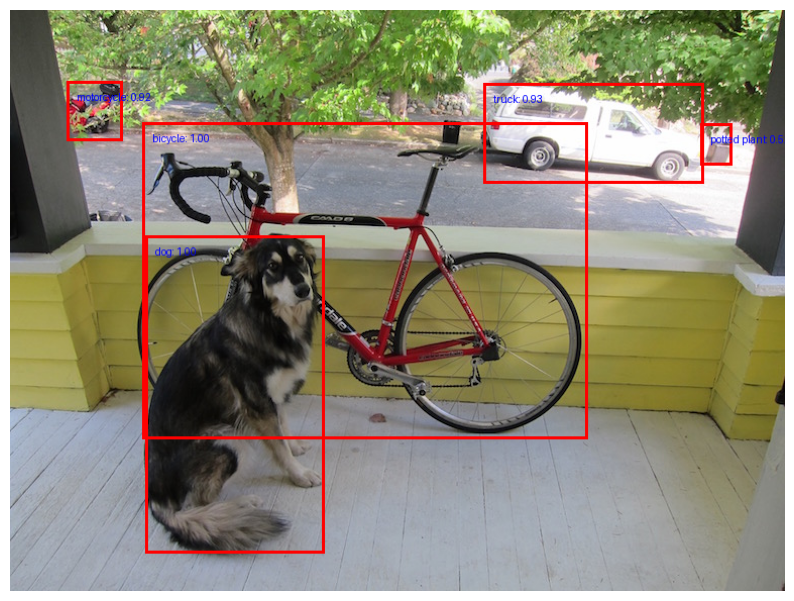


Evaluating image: ../Description/image2.jpg

Detected 14 object(s):
1. car
   Confidence : 1.00
   Box        : (x1=852, y1=517, x2=1131, y2=683)
   Size       : width=279, height=166
   Center     : (cx=991, cy=600)

2. car
   Confidence : 1.00
   Box        : (x1=490, y1=519, x2=551, y2=563)
   Size       : width=61, height=44
   Center     : (cx=520, cy=541)

3. car
   Confidence : 1.00
   Box        : (x1=281, y1=511, x2=380, y2=574)
   Size       : width=99, height=63
   Center     : (cx=330, cy=542)

4. car
   Confidence : 1.00
   Box        : (x1=554, y1=522, x2=582, y2=543)
   Size       : width=28, height=21
   Center     : (cx=568, cy=532)

5. car
   Confidence : 0.99
   Box        : (x1=602, y1=521, x2=645, y2=555)
   Size       : width=43, height=34
   Center     : (cx=623, cy=538)

6. car
   Confidence : 0.98
   Box        : (x1=577, y1=520, x2=596, y2=539)
   Size       : width=19, height=19
   Center     : (cx=586, cy=529)

7. car
   Confidence : 0.97
   Box        : (x

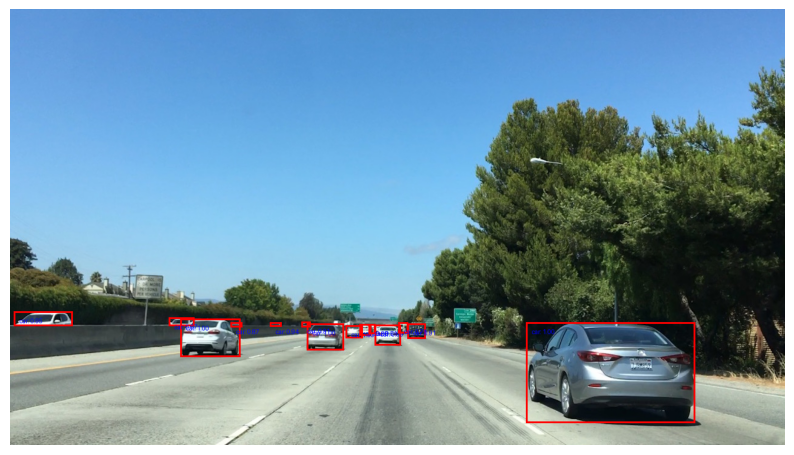

In [7]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np



weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
model.eval()
model.to('cpu')


COCO_CLASSES = weights.meta['categories']

transform = weights.transforms()

def frcnn_detect(img, threshold=0.5):
    # Complete the function to do the functionality of FRCNN for object detection
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        prediction = model(img_tensor)

    boxes = prediction[0]['boxes'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    valid_indices = np.where(scores > threshold)[0]

    img_with_boxes = img.copy()
    draw = ImageDraw.Draw(img_with_boxes)

    print(f"\nDetected {len(valid_indices)} object(s):")

    for i, idx in enumerate(valid_indices, start=1):
        box = boxes[idx]
        label = labels[idx]
        score = scores[idx]

        x1, y1, x2, y2 = map(int, box)
        width = x2 - x1
        height = y2 - y1
        center_x = x1 + width // 2
        center_y = y1 + height // 2

        class_name = COCO_CLASSES[label]

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        draw.text((x1 + 10, y1 + 10),
                  f"{class_name}: {score:.2f}",
                  fill="blue")

        print(
            f"{i}. {class_name}\n"
            f"   Confidence : {score:.2f}\n"
            f"   Box        : (x1={x1}, y1={y1}, x2={x2}, y2={y2})\n"
            f"   Size       : width={width}, height={height}\n"
            f"   Center     : (cx={center_x}, cy={center_y})\n"
        )


    plt.figure(figsize=(10, 10))
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()

    return img_with_boxes


# Feed Image1 and Image2 to the model and evaluate it
image_paths = [
    "../Description/image1.jpg",
    "../Description/image2.jpg"
]

for path in image_paths:
    print(f"\nEvaluating image: {path}")
    img = Image.open(path).convert("RGB")
    result_img = frcnn_detect(img)


Evaluating image: ../Description/image1.jpg

Detected 21 object(s):
1. bicycle
   Confidence : 1.00
   Box        : (x1=131, y1=112, x2=572, y2=425)
   Size       : width=441, height=313
   Center     : (cx=351, cy=268)

2. dog
   Confidence : 1.00
   Box        : (x1=134, y1=224, x2=311, y2=538)
   Size       : width=177, height=314
   Center     : (cx=222, cy=381)

3. truck
   Confidence : 0.93
   Box        : (x1=469, y1=73, x2=687, y2=172)
   Size       : width=218, height=99
   Center     : (cx=578, cy=122)

4. motorcycle
   Confidence : 0.92
   Box        : (x1=56, y1=71, x2=111, y2=130)
   Size       : width=55, height=59
   Center     : (cx=83, cy=100)

5. potted plant
   Confidence : 0.52
   Box        : (x1=684, y1=113, x2=715, y2=154)
   Size       : width=31, height=41
   Center     : (cx=699, cy=133)

6. bicycle
   Confidence : 0.47
   Box        : (x1=121, y1=140, x2=367, y2=375)
   Size       : width=246, height=235
   Center     : (cx=244, cy=257)

7. bicycle
   Confid

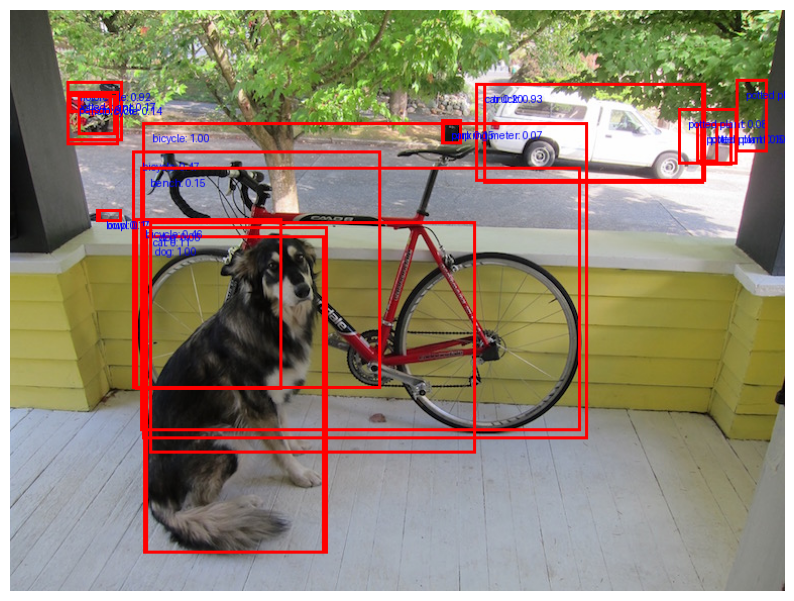


Evaluating image: ../Description/image2.jpg

Detected 28 object(s):
1. car
   Confidence : 1.00
   Box        : (x1=852, y1=517, x2=1131, y2=683)
   Size       : width=279, height=166
   Center     : (cx=991, cy=600)

2. car
   Confidence : 1.00
   Box        : (x1=490, y1=519, x2=551, y2=563)
   Size       : width=61, height=44
   Center     : (cx=520, cy=541)

3. car
   Confidence : 1.00
   Box        : (x1=281, y1=511, x2=380, y2=574)
   Size       : width=99, height=63
   Center     : (cx=330, cy=542)

4. car
   Confidence : 1.00
   Box        : (x1=554, y1=522, x2=582, y2=543)
   Size       : width=28, height=21
   Center     : (cx=568, cy=532)

5. car
   Confidence : 0.99
   Box        : (x1=602, y1=521, x2=645, y2=555)
   Size       : width=43, height=34
   Center     : (cx=623, cy=538)

6. car
   Confidence : 0.98
   Box        : (x1=577, y1=520, x2=596, y2=539)
   Size       : width=19, height=19
   Center     : (cx=586, cy=529)

7. car
   Confidence : 0.97
   Box        : (x

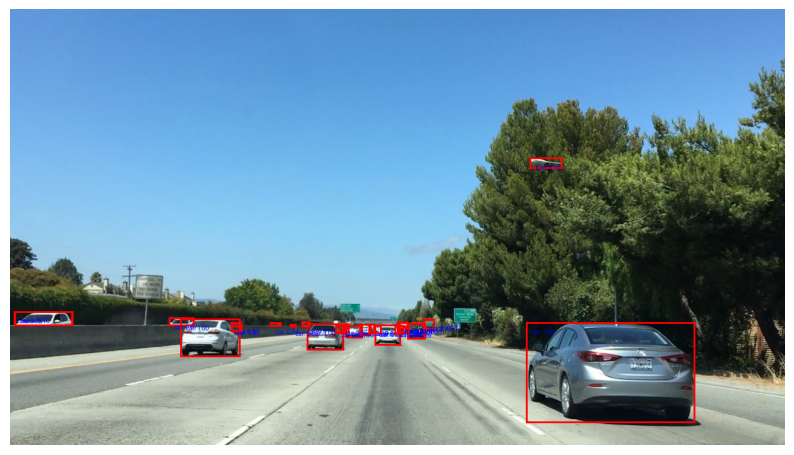

In [8]:
image_paths = [
    "../Description/image1.jpg",
    "../Description/image2.jpg"
]

for path in image_paths:
    print(f"\nEvaluating image: {path}")
    img = Image.open(path).convert("RGB")
    result_img = frcnn_detect(img, threshold=0)

### **Analysis & Observations**

<div dir="rtl">


## نتایج و تحلیل (Results and Analysis)

با مقایسه‌ی خروجی‌های مدل در دو حالت **threshold = 0** و **threshold = 0.5** می‌توان رفتار داخلی شبکه‌ی **Region Proposal Network (RPN)** را به‌خوبی مشاهده کرد. وقتی آستانه‌ی اطمینان روی صفر قرار داده می‌شود، مدل تقریباً تمام نواحی‌ای که حتی احتمال خیلی کمی برای وجود شیء دارند را هم به‌صورت باکس نمایش می‌دهد. نتیجه‌ی این کار، تصاویری بسیار شلوغ است که پر از باکس‌های تکراری یا پیش‌بینی‌های اشتباه با اعتماد بسیار پایین (مثلاً کمتر از 0.2) هستند. این موضوع به‌خصوص در تصاویری با جزئیات زیاد مثل صحنه‌ی ایوان خانه (porch) کاملاً مشهود است و باعث ایجاد نویز بصری شدید می‌شود.

در مقابل، وقتی آستانه‌ی اطمینان روی **0.5** تنظیم می‌شود، تنها پیش‌بینی‌هایی نمایش داده می‌شوند که مدل نسبت به آن‌ها اعتماد بالایی دارد. این کار باعث می‌شود باکس‌های ضعیف و غیرقابل‌اعتماد حذف شوند و خروجی نهایی بسیار تمیزتر و قابل‌فهم‌تر شود. این مقایسه به‌خوبی نشان می‌دهد که مرحله‌ی **post-processing** و تنظیم آستانه‌ی اطمینان، بخش بسیار مهمی از پایپ‌لاین تشخیص اشیاء است و بدون آن، خروجی مدل عملاً کاربردی نخواهد بود.


### تحلیل تصویر اول: صحنه‌ی ایوان (Porch Scene)

در تصویر اول، مدل عملکرد بسیار خوبی در شناسایی اشیاء مختلف از خود نشان داده است. اشیائی مثل **سگ، دوچرخه، موتورسیکلت و کامیون** با دقت بالا تشخیص داده شده‌اند و اکثر آن‌ها دارای نمره‌ی اطمینان بالاتر از **0.9** هستند. این موضوع نشان می‌دهد که این کلاس‌ها به‌خوبی در دیتاست **COCO** نمایش داده شده‌اند و مدل در تشخیص آن‌ها کاملاً آموزش دیده است.

یکی از چالش‌های اصلی این تصویر، مسئله‌ی **پوشیدگی (Occlusion)** است؛ جایی که سگ جلوی دوچرخه نشسته و بخش زیادی از آن را پوشانده است. با این حال، مدل Faster R-CNN توانسته این دو شیء را به‌درستی از هم تفکیک کند و برای دوچرخه، حتی با وجود دیده شدن فقط بخشی از آن، باکس جداگانه‌ای رسم کند. علاوه بر این، مدل توانسته اشیاء موجود در پس‌زمینه مثل موتورسیکلت و کامیون را نیز تشخیص دهد، که نشان‌دهنده‌ی توانایی خوب مدل در تفکیک اشیاء پیش‌زمینه و پس‌زمینه است.

### تحلیل تصویر دوم: صحنه‌ی بزرگراه (Highway Scene)

تصویر دوم به‌خوبی قدرت **Feature Pyramid Network (FPN)** را نشان می‌دهد. در این تصویر، مدل هم اشیاء بزرگ نزدیک به دوربین و هم اشیاء بسیار کوچک و دور را با دقت تشخیص داده است. برای مثال، خودروی نقره‌ای‌رنگ در سمت راست تصویر که در پیش‌زمینه قرار دارد، با نمره‌ی اطمینان کامل **1.00** شناسایی شده است. در عین حال، چندین خودرو کوچک در فاصله‌ی دور و نزدیک خط افق نیز به‌درستی تشخیص داده شده‌اند.

بدون وجود FPN، بسیاری از مدل‌های CNN معمولی در تشخیص این اشیاء کوچک دچار مشکل می‌شوند، چون ویژگی‌های آن‌ها در لایه‌های عمیق‌تر شبکه از بین می‌رود. اما استفاده از نقشه‌های ویژگی در چند مقیاس مختلف در FPN باعث می‌شود مدل بتواند این اشیاء دوردست را هم «ببیند». همچنین، در خروجی با **threshold = 0** مقداری نویز در نواحی شلوغ مثل بافت درخت‌ها دیده می‌شود، اما با اعمال آستانه‌ی **0.6** این پیش‌بینی‌های اشتباه حذف شده‌اند. البته در این فرآیند، تشخیص چراغی که داخل برگ‌ها قرار داشته نیز از دست رفته است که نشان می‌دهد انتخاب مقدار threshold همیشه یک **trade-off** بین حذف نویز و از دست دادن بعضی تشخیص‌های درست است.


## 4. Task 3 – Semantic Segmentation

In this task, you are to use the pretrained **DeepLabV3+ with ResNet50 backbone (torchvision)** model for a segemntation task.

<span style="color:red">
Load the model using the "COCO_WITH_VOC_LABELS_V1" weights.

Do the required preprocessing
</span>

<div dir="rtl">

## معرفی مدل (Model Overview)

در این بخش از مدل **DeepLabV3+** برای انجام وظیفه‌ی **بخش‌بندی معنایی تصویر (Semantic Segmentation)** استفاده شده است. برخلاف مدل‌های تشخیص شیء که فقط دور اشیاء باکس می‌کشند، DeepLabV3+ هر **پیکسل** از تصویر را بررسی می‌کند و مشخص می‌کند که متعلق به چه کلاسی است. این مدل یکی از معماری‌های پیشرفته و به‌روز در حوزه‌ی سگمنتیشن محسوب می‌شود و برای صحنه‌های واقعی با اشیاء در اندازه‌های مختلف عملکرد بسیار خوبی دارد.

DeepLabV3+ برای استخراج بهتر اطلاعات از تصویر از تکنیکی به نام **Atrous یا Dilated Convolution** استفاده می‌کند. این نوع کانولوشن باعث می‌شود میدان دید فیلترها بزرگ‌تر شود، بدون اینکه اندازه‌ی نقشه‌های ویژگی (feature maps) کوچک شود. نتیجه‌ی این کار این است که مدل می‌تواند هم جزئیات دقیق لبه‌ها را حفظ کند و هم اطلاعات کلی صحنه و ارتباط بین اشیاء مختلف را درک کند. این ویژگی مخصوصاً برای تشخیص اشیاء بزرگ و کوچک در کنار هم اهمیت زیادی دارد.

در پیاده‌سازی ما، ستون فقرات (Backbone) مدل **ResNet-50** است که وظیفه‌ی استخراج ویژگی‌های غنی و معنایی از تصویر را بر عهده دارد. استفاده از ResNet-50 باعث می‌شود مدل بتواند الگوهای پیچیده، بافت‌ها و ساختارهای مهم تصویر را به‌خوبی یاد بگیرد. وزن‌های استفاده‌شده در این مدل از نوع **COCO_WITH_VOC_LABELS_V1** هستند؛ یعنی مدل ابتدا روی دیتاست **COCO** آموزش دیده اما خروجی آن بر اساس فضای برچسب‌های **PASCAL VOC** تنظیم شده است. در نتیجه، مدل قادر است **۲۱ کلاس مختلف** (۲۰ کلاس شیء به‌همراه کلاس پس‌زمینه) را برای هر پیکسل تشخیص دهد.

## پیش‌پردازش و نمایش خروجی (Preprocessing & Visualization)

برای اینکه تصاویر ورودی با شرایطی که مدل روی آن آموزش دیده هماهنگ باشند، یک پایپ‌لاین پیش‌پردازش مشخص در نظر گرفته شده است. ابتدا همه‌ی تصاویر به اندازه‌ی ثابت **۵۲۰×۵۲۰ پیکسل** تغییر داده می‌شوند تا ورودی مدل یکنواخت باشد. سپس تصویر به **Tensor** تبدیل می‌شود و در نهایت با استفاده از میانگین و انحراف معیار استاندارد **ImageNet** نرمال‌سازی می‌شود. این مرحله بسیار مهم است چون باعث می‌شود توزیع داده‌های ورودی با داده‌هایی که مدل در زمان آموزش دیده هم‌خوانی داشته باشد و خروجی مدل دقیق‌تر شود.

خروجی خام مدل برای هر پیکسل یک **اندیس کلاس** است. برای قابل‌فهم شدن این خروجی، هر اندیس به رنگ مخصوص خودش بر اساس **پالت رنگ استاندارد PASCAL VOC** نگاشت می‌شود؛ برای مثال پس‌زمینه به رنگ مشکی، ماشین به خاکستری، انسان به رنگ صورتی متمایل به قرمز و سایر اشیاء هر کدام با رنگ مشخص نمایش داده می‌شوند. این کار باعث می‌شود ماسک سگمنتیشن به‌صورت بصری واضح و قابل تحلیل باشد.

در نهایت، برای بررسی میزان هم‌خوانی خروجی مدل با تصویر اصلی، یک تصویر **Overlay** ساخته شده است. در این مرحله، تصویر اصلی (پس از تغییر اندازه) با ماسک رنگی سگمنتیشن ترکیب می‌شود، به‌طوری که **۶۰٪ تصویر اصلی** و **۴۰٪ ماسک سگمنتیشن** در خروجی نهایی دیده می‌شود. این ترکیب به ما کمک می‌کند ببینیم مرزهای پیش‌بینی‌شده توسط مدل تا چه حد با اشیاء واقعی داخل تصویر هم‌راستا هستند و کیفیت کلی سگمنتیشن به‌صورت بصری ارزیابی شود.

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 169MB/s]



Segmenting: ../Description/image2.jpg


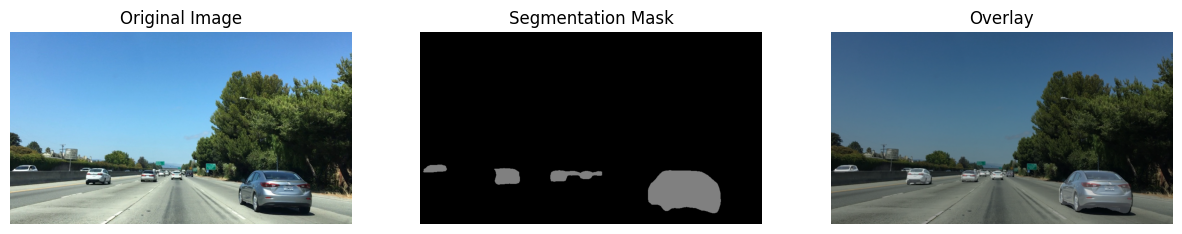


Class Distribution in the Image:
background     : 49.51%
car            : 2.63%

Classes Present in the Image:
background, car

Segmenting: ../Description/image3.jpg


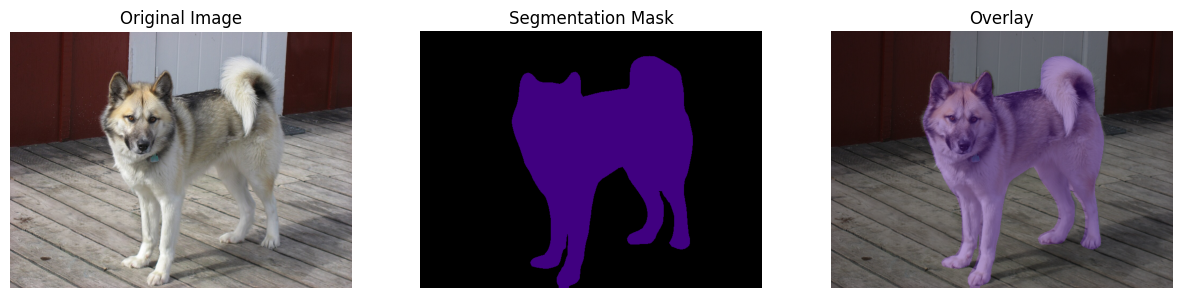


Class Distribution in the Image:
background     : 21.35%
dog            : 7.98%

Classes Present in the Image:
background, dog

Segmenting: ../Description/image6.jpg


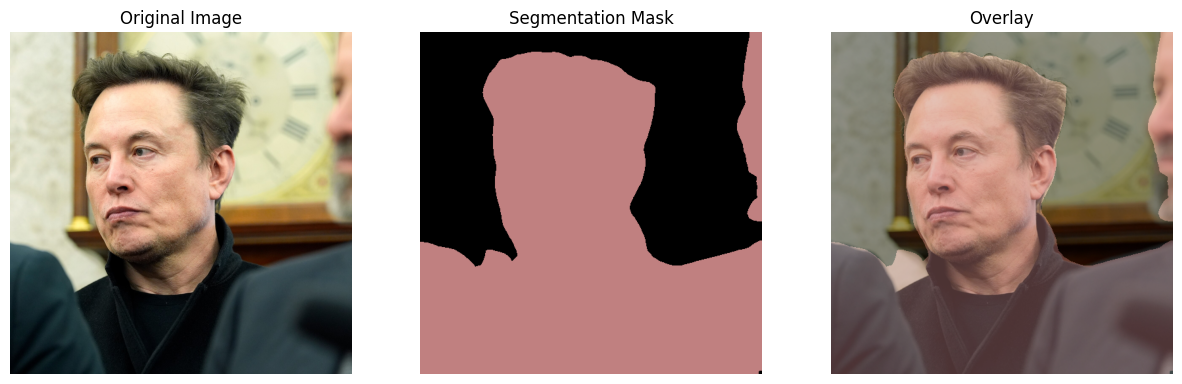


Class Distribution in the Image:
background     : 3.89%
person         : 6.41%

Classes Present in the Image:
background, person


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
seg_model = deeplabv3_resnet50(weights=weights)
seg_model.eval()
seg_model.to(device)


seg_preprocess = transforms.Compose([
    transforms.Resize(520),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# seg_preprocess = weights.transforms()

# PASCAL VOC colors (21 classes)
VOC_COLORS = np.array([
    [0, 0, 0],      # background
    [128, 0, 0],    # aeroplane
    [0, 128, 0],    # bicycle
    [128, 128, 0],  # bird
    [0, 0, 128],    # boat
    [128, 0, 128],  # bottle
    [0, 128, 128],  # bus
    [128, 128, 128],# car
    [64, 0, 0],     # cat
    [192, 0, 0],    # chair
    [64, 128, 0],   # cow
    [192, 128, 0],  # dining table
    [64, 0, 128],   # dog
    [192, 0, 128],  # horse
    [64, 128, 128], # motorbike
    [192, 128, 128],# person
    [0, 64, 0],     # potted plant
    [128, 64, 0],   # sheep
    [0, 192, 0],    # sofa
    [128, 192, 0],  # train
    [0, 192, 128]   # tv/monitor
])


VOC_CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "dining table", "dog",
    "horse", "motorbike", "person", "potted plant", "sheep", "sofa",
    "train", "tv/monitor"
]

def segment_image(img):
    input_tensor = seg_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = seg_model(input_tensor)['out'][0]
    pred = output.argmax(0).cpu().numpy()

    # Create colored mask
    color_mask = VOC_COLORS[pred]

    # Overlay
    img_np = np.array(img.resize((pred.shape[1], pred.shape[0])))
    overlay = (0.6 * img_np + 0.4 * color_mask).astype(np.uint8)

    # Plot the orginal image and preprocessed version.
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(color_mask)
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.show()


    # useful informations
    unique, counts = np.unique(pred, return_counts=True)
    class_counts = dict(zip(unique, counts))
    total_pixels = img.size[0] * img.size[1]
    print("\nClass Distribution in the Image:")
    for class_id, count in class_counts.items():
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else "Unknown"
        percentage = (count / total_pixels) * 100
        print(f"{class_name:15}: {percentage:.2f}%")
    present_classes = [VOC_CLASSES[class_id] for class_id in unique if class_id < len(VOC_CLASSES)]
    print("\nClasses Present in the Image:")
    print(", ".join(present_classes) if present_classes else "No classes detected")

    return pred

# Evaluate the model on Image2, Image3, and Image6
image_paths = [
    "../Description/image2.jpg",
    "../Description/image3.jpg",
    "../Description/image6.jpg"
]

for path in image_paths:
    print(f"\nSegmenting: {path}")
    img = Image.open(path).convert("RGB")
    segment_image(img)

### **Analysis & Observations**

<div dir="rtl">

مدل **DeepLabV3+ با ستون فقرات ResNet-50** روی سه نوع صحنه‌ی متفاوت آزمایش شد: یک تصویر پرتره، یک حیوان در محیط طبیعی و یک صحنه‌ی شلوغ ترافیکی. برای نمایش نتایج، خروجی سگمنتیشن به‌صورت یک تصویر ترکیبی نمایش داده شد که در آن **۶۰٪ تصویر اصلی** و **۴۰٪ ماسک سگمنتیشن** با هم ترکیب شده‌اند. این روش نمایش کمک می‌کند تا میزان تطابق مرزهای پیش‌بینی‌شده با اشیاء واقعی داخل تصویر به‌صورت بصری و واضح بررسی شود.

### تحلیل تصویر ۲: صحنه‌ی بزرگراه (محدودیت کلاس‌ها)

در تصویر بزرگراه، خروجی مدل نشان می‌دهد که فقط **وسایل نقلیه** با رنگ خاکستری (کلاس Car) سگمنت شده‌اند و سایر بخش‌ها مثل جاده، آسمان و پوشش گیاهی به رنگ مشکی باقی مانده‌اند. این موضوع در نگاه اول ممکن است شبیه ضعف مدل به نظر برسد، اما در واقع کاملاً به **محدودیت دیتاست آموزشی** برمی‌گردد، نه عملکرد خود مدل. چون مدل روی فضای برچسب‌های **PASCAL VOC** آموزش دیده که فقط شامل ۲۱ کلاس است و کلاس‌هایی مثل «جاده»، «آسمان» یا «گیاهان» در آن وجود ندارند، این نواحی به‌درستی به‌عنوان **پس‌زمینه (Background)** با اندیس صفر برچسب خورده‌اند.

از نظر مقیاس اشیاء، خودروهایی که به دوربین نزدیک‌تر هستند با دقت بسیار خوبی سگمنت شده‌اند. در مقابل، خودروهای دورتر که تعداد پیکسل‌های بسیار کمی را اشغال می‌کنند، به‌صورت لکه‌های کوچک‌تری دیده می‌شوند. این موضوع نشان می‌دهد که مدل به‌طور کلی با تغییر مقیاس کنار می‌آید، اما طبیعتاً در سگمنتیشن پیکسلی، دقت مرزها برای اشیاء خیلی کوچک کاهش پیدا می‌کند.

### تحلیل تصویر ۳: حیوان (سگ)

در تصویر مربوط به سگ، مدل عملکرد بسیار خوبی از نظر **تفکیک معنایی** نشان داده است. با وجود شباهت نسبی رنگ خز قسمت پایینی سگ با سطح چوبی زیر آن، مدل توانسته سگ (کلاس Dog با اندیس ۱۲ و رنگ بنفش) را به‌درستی از پس‌زمینه جدا کند. این موضوع نشان می‌دهد که مدل فقط به رنگ تکیه نمی‌کند، بلکه از ویژگی‌های معنایی و ساختاری که توسط ResNet-50 استخراج شده‌اند استفاده می‌کند.

همچنین ماسک سگمنتیشن تقریباً تمام بخش‌های مهم بدن سگ، مثل گوش‌ها و دم پُرپشت را در بر گرفته است. این موضوع نشان‌دهنده‌ی میدان دید مؤثر و مناسب مدل است که باعث می‌شود اجزای اصلی شیء حتی در صورت پیچیدگی ظاهری، به‌خوبی پوشش داده شوند.

### تحلیل تصویر ۶: پرتره (ایلان ماسک)

در تصویر پرتره، مدل به‌درستی سوژه را به‌عنوان **Person** (اندیس ۱۵، رنگ صورتی استاندارد VOC) تشخیص داده است. ماسک سگمنتیشن به‌خوبی با فرم کلی صورت و لباس هماهنگ شده و مرزهای اصلی به‌درستی دنبال شده‌اند. این موضوع نشان می‌دهد که مدل در تشخیص ساختارهای کلی انسان عملکرد قابل اعتمادی دارد.

البته یکی از چالش‌های قابل مشاهده در این تصویر، ناحیه‌ی **موها** است. مرزهای اطراف مو کمی صاف و هموار شده‌اند و جزئیات خیلی ریز مثل تارهای جداگانه‌ی مو به‌طور کامل حفظ نشده‌اند. این مسئله یک محدودیت رایج در مدل‌های سگمنتیشن معنایی است، چون به دلیل عملیات downsampling در شبکه‌های کانولوشنی، جزئیات با فرکانس بالا معمولاً از بین می‌روند. با این حال، شکل کلی سر به‌درستی استخراج شده و پس‌زمینه‌ی محو تصویر نیز به‌درستی به‌عنوان پس‌زمینه نادیده گرفته شده است.
